# Modello ADAF del disco di accrescimento
Uso programma di Chiara Righi

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.special import kv  # Bessel K

# ==========================================================
# COSTANTI
# ==========================================================
ALFA = 0.3  # parametro di viscosità=quanto efficientemente il momento angolare viene trasportato verso l’esterno
RMIN = 3.0 # rmin in unità di Schwarzschild
RMAX = 1000.0 # rmax in unità di Schwarzschild
DELTA = 0.0 # 

C1 = 0.5 # coefficiente per la velocità radiale
C3 = 0.3 # coefficiente per la temperatura ionica
TNORM = 1.68e-10 # temperatura normale per la conversione in unità di energia (k_B*T in erg)

In [142]:
# ==========================================================
# FUNZIONI MATEMATICHE
# ==========================================================
def bessk(n, x):  # funzione di Bessel K di ordine n e argomento x 
    return kv(n, x)

def g(teta):   # funzione g(teta) 
    return (1.0 / bessk(2, 1.0 / teta)) * (2.0 + 2.0 * teta + 1.0 / teta) * np.exp(-1.0 / teta)

In [143]:
# ==========================================================
# SISTEMA NON LINEARE
# ==========================================================

def temperat(y, mdot, m, beta):

    ff = y[2]**2
    xm = 1e3 * y[1]**2
    teta = y[0]**2

    s1 = 1.42e9 * ALFA**(-0.5) * np.sqrt(1 - beta) * C1**(-0.5) * C3**0.5
    s2 = 1.19e-13 * xm

    # --- Heating ---
    q1 = 1.2e4 * g(teta) * ALFA**(-2) * C1**(-2) * C3 * beta * m * mdot**2 / RMIN
    q2 = DELTA * 9.39e4 * ((1 - beta) / ff) * C3 * m * mdot / RMIN
    q = q1 + q2

    # --- Synchrotron ---
    nup = s1 * s2 * m**(-0.5) * mdot**0.5 * (teta / TNORM)**2 * RMIN**(-5/4)

    psinc = (
        53.0 * (xm / 1000.0)**3 *
        (teta / (1e9 * TNORM))**7 *
        m**0.5 * mdot**1.5
    )

    # --- Compton ---
    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot
    alfac = -np.log(tau) / np.log(abig)

    graffa = ((6.2e7 * (teta / (1e9 * TNORM))) / (nup * 1e-12))**(1 - alfac) - 1
    pcomp = (psinc / 0.71) / (1 - alfac) * graffa

    # --- Brems ---
    if teta < 1:
        f = 4*np.sqrt(2*teta/np.pi**3) * (1 + 1.781*teta**1.34)
    else:
        f = (9*teta/(2*np.pi)) * (np.log(1.123*teta + 0.48) + 1.5)

    pbrems = 4.78 * ALFA**(-2) * C1**(-2) * np.log(RMAX/RMIN) * f * m * mdot**2

    # --- Equazioni ---
    f1 = q - psinc - pcomp - pbrems
    f2 = (1 - ff) * 9.39e4 * ((1 - beta) / ff) * C3 * m * mdot / RMIN - q

    vv = xm**(1/3)
    f3 = (
        vv + 1.852*np.log(vv)
        - 10.36
        - 0.26*np.log(m*mdot)
        + 0.26*np.log(teta**3 * bessk(2, 1/teta))
    )

    return [f1, f3, f2]


In [144]:
# ==========================================================
# SPETTRO
# ==========================================================

def spectrum(te, f, xm, m, mdot, beta, savefile=None):

    numin = 1e10
    numax = 1e21
    num = 100

    lnu = np.linspace(np.log10(numin), np.log10(numax), num)
    nu = 10**lnu

    teta = 1.68e-10 * te

    s1 = 1.42e9 * ALFA**(-0.5) * np.sqrt(1 - beta) * C1**(-0.5) * C3**0.5
    s2 = 1.19e-13 * xm
    s3 = 1.05e-24

    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot
    alfac = -np.log(tau) / np.log(abig)

    lnup = np.log10(s1 * s2 * m**(-0.5) * mdot**0.5 * te**2 * RMIN**(-5/4))
    lnucmax = np.log10(te) + 10.796

    # coefficiente sinc
    llsinc = (
        3*np.log10(s1*s2)
        + np.log10(s3)
        - (7/4)*np.log10(RMIN)
        + np.log10(m**0.5 * mdot**1.5)
        + 7*np.log10(te)
    )

    lls = np.zeros(num)
    llc = np.zeros(num)
    llb = np.zeros(num)

    for i in range(num):

        # ---------------- SYNCHROTRON ----------------
        if lnu[i] < lnup:
            lls[i] = (
                np.log10(s3)
                + (8/5)*np.log10(s1*s2)
                + np.log10(m**(6/5) * mdot**(4/5))
                + (21/5)*np.log10(te)
                + (2/5)*lnu[i]
            )
        else:
            lls[i] = 0.0

        # ---------------- COMPTON ----------------
        if lnu[i] > lnup:
            base = llsinc + (alfac - 1)*lnup - alfac*lnu[i]
            cutoff = -(10**(lnu[i] - lnucmax)) / np.log(10)
            llc[i] = base + cutoff
        else:
            llc[i] = 0.0

        # ---------------- BREMS ----------------
        if teta < 1:
            fb = 4*np.sqrt(2*teta/np.pi**3) * (1 + 1.781*teta**1.34)
        else:
            fb = (9*teta/(2*np.pi)) * (np.log(1.123*teta + 0.48) + 1.5)

        base_b = (
            24.36
            - 2*np.log10(ALFA*C1)
            + np.log10(np.log(RMAX/RMIN) * fb)
            - np.log10(te)
            + np.log10(m * mdot**2)
        )

        cutoff_b = -(4.8e-11 * nu[i] / te) / np.log(10)
        llb[i] = base_b + cutoff_b

    flux = 10**lls + 10**llc + 10**llb
    y = lnu + np.log10(flux)

# QUI CAMBIO RISPETTO AL CODICE ORIGINALE DI RIGHI, non mi faccio plottare le singole componenti, ma solo la somma totale
    if savefile is not None:
        np.savetxt(savefile, np.column_stack([lnu, y]))
        print(f"File salvato: {savefile}")

    return lnu, y, lls, llc, llb

In [145]:
# ==========================================================
# specdata
# ==========================================================

def specdata(m, mdot, beta, savefile=None, verbose=True):  #verbose serve per stampare i parametri di input, se verbose è True, altrimenti no

    if verbose:
        print(f"m = {m}")
        print(f"mdot = {mdot}")
        print(f"beta = {beta}")

    y0 = [0.5, 1.0, 0.99]  # valori iniziali per teta, xm e f (in unità di radice quadrata)

    sol = root(temperat, y0, args=(mdot, m, beta), tol=1e-10)

    if not sol.success:
        print("Non converge")

    y = sol.x

    teta = y[0]**2
    te = teta / 1.68e-10
    xm = 1e3 * y[1]**2
    f = y[2]**2

    if verbose:
        print("\n=== OUTPUT ===")
        print("te   =", te)
        print("xm   =", xm)
        print("f    =", f)

    lnu, spettro_tot, lls, llc, llb = spectrum(te, f, xm, m, mdot, beta, savefile=savefile)

    return {
        "lnu": lnu,
        "log_nuFnu": spettro_tot,
        "log_sync": lls,
        "log_compton": llc,
        "log_brems": llb,
        "te": te,
        "xm": xm,
        "f": f,
        "m": m,
        "mdot": mdot,
        "beta": beta
    }

In [146]:
# ==========================================================
# PLOT DI PIU' SCENARI
# ==========================================================

def plot_scenari_righi(scenari):

    plt.figure(figsize=(8, 6))

    for sc in scenari:
        risultato = specdata(
            m=sc["m"],
            mdot=sc["mdot"],
            beta=sc["beta"],
            savefile=sc.get("savefile", None),
            verbose=sc.get("verbose", False)
        )

        plt.plot(
            risultato["lnu"],
            risultato["log_nuFnu"],
            label=sc.get("label", f'm={sc["m"]:.1e}, mdot={sc["mdot"]:.1e}, beta={sc["beta"]}'),
            color=sc.get("color", None),
            linewidth=2
        )

    plt.xlabel("log nu [Hz]")
    plt.ylabel("log nu*Fnu [erg/s/cm^2]")
    plt.legend()
    plt.show()

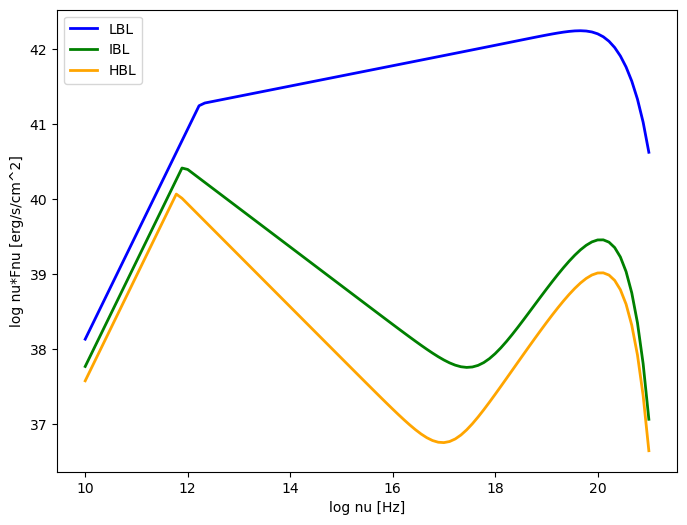

In [147]:
# ==========================================================
# DATI PRESI DA ARTICOLO CHIARA RIGHI
# ==========================================================
scenari = [
    {
        "m": 1e9,
        "mdot": 5.7e-3,
        "beta": 0.5,
        "color": "blue",
        "label": "LBL"},
    {
        "m": 1e9,
        "mdot": 0.5e-3,
        "beta": 0.5,
        "color": "green",
        "label": "IBL"},
    {
        "m": 1e9,
        "mdot": 0.3e-3,
        "beta": 0.5,
        "color": "orange",
        "label": "HBL"}
]

plot_scenari_righi(scenari)

OSS: vedo che torna con il grafico in figura 2 dell'articolo di Chiara Righi

In [148]:
# ==========================================================
# PLOT DI PIU' SCENARI
# ==========================================================
def plot_scenari_mahadevan(scenari):

    plt.figure(figsize=(8, 6))

    for sc in scenari:
        risultato = specdata(
            m=sc["m"],
            mdot=sc["mdot"],
            beta=sc["beta"],
            savefile=sc.get("savefile", None),
            verbose=sc.get("verbose", False)
        )

        plt.plot(
            risultato["lnu"],
            risultato["log_nuFnu"],
            label=sc.get("label", f'm={sc["m"]:.1e}, mdot={sc["mdot"]:.1e}, beta={sc["beta"]}'),
            color=sc.get("color", None),
            linewidth=2
        )

    plt.xlabel("log nu [Hz]")
    plt.ylabel("log nu*Fnu [erg/s/cm^2]")
    #plt.ylim(35.5, 42.5)
    plt.legend()
    plt.show()

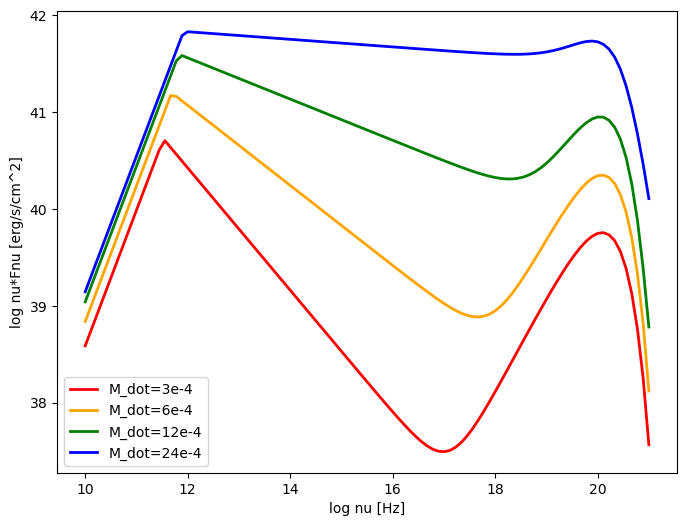

In [149]:
# ==========================================================
# DATI PRESI DA ARTICOLO MAHADEVAN
# ==========================================================
scenari = [
    {
        "m": 5e9,
        "mdot": 3e-4,
        "beta": 0.5,
        "color": "red",
        "label": "M_dot=3e-4" },
    {
        "m": 5e9,
        "mdot": 6e-4,
        "beta": 0.5,
        "color": "orange",
        "label": "M_dot=6e-4" },
    {
        "m": 5e9,
        "mdot": 12e-4,
        "beta": 0.5,
        "color": "green",
        "label": "M_dot=12e-4" },
    {
        "m": 5e9,
        "mdot": 24e-4,
        "beta": 0.5,
        "color": "blue",
        "label": "M_dot=24e-4" }
]

plot_scenari_mahadevan(scenari)

OSS: vedo che torna con il grafico in figura 1 dell'articolo di Mahadevan  

ATTENZIONE: 1) SULL'ASSE DELLE Y HO: er/s oppure er/sec/cm^2 come nell'articolo di Righi?  
            2) non ho coda a sx come nell'articolo di mahadevan, come faccio ad ottenerla? cosa vuol dire? è utile?